In [1]:
import os
os.chdir("../")

In [2]:
!pwd

/home/vanishhhed/Desktop/codics/PythonCodics/ML/XAI/Grad-Cam


In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image

from src.dataset.dataset import _load_config
from src.models.efficientemotionnet import EfficientEmotionNet
from src.gradcam.grad_cam import GradCAM as MyGradCAM

config = _load_config()
MODEL_PATH = config["models"]["efficientnet"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

emotion_labels = {
    0: "Anger", 1: "Disgust", 2: "Fear", 3: "Happy",
    4: "Sad", 5: "Surprise", 6: "Neutral",
}

Using device: cpu


In [4]:
model = EfficientEmotionNet(num_classes=7, dropout=0.4)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

display_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

val_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/vanishhhed/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 12.6MB/s]


In [ ]:
target_layer_name = "model.features.8"
named_modules = dict(model.named_modules())
if target_layer_name not in named_modules:
    available = [
        k for k in named_modules
        if "conv" in k or "features" in k or "res_blocks" in k
    ][:20]
    raise ValueError(
        f"Layer '{target_layer_name}' not found!\n"
        f"Available layers (sample): {available}"
    )
    
target_layer = named_modules[target_layer_name]
print(type(target_layer))

<class 'torchvision.ops.misc.Conv2dNormActivation'>


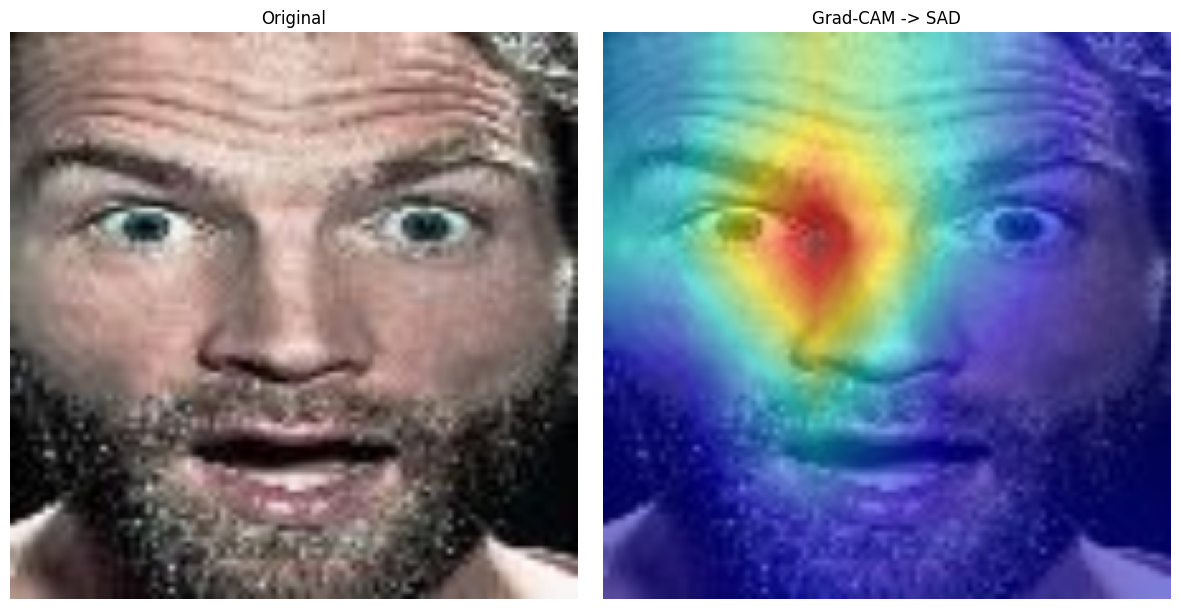

In [7]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

with GradCAM(model=model, target_layers=[target_layer]) as cam:
    
    with torch.no_grad():
        logits = model(input_tensor)
        predicted_class = torch.argmax(logits, dim=1).item()
        # probabilities = torch.softmax(logits, dim=1)[0]
        
    targets = [ClassifierOutputTarget(predicted_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
rgb_img = np.array(img_display) / 255.0

cam_tensor = torch.from_numpy(grayscale_cam).unsqueeze(0).unsqueeze(0)  # [1, 1, 48, 48]
cam_resized = F.interpolate(
    cam_tensor,
    size=(rgb_img.shape[0], rgb_img.shape[1]),   # 100×100
    mode='bilinear',
    align_corners=False
).squeeze().numpy()

visualization = show_cam_on_image(rgb_img, cam_resized, use_rgb=True)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"Grad-CAM -> {emotion_labels[predicted_class].upper()}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
my_gradcam = MyGradCAM(model, target_layer)

def test_my_gradcam(*, path_to_image:str, model=model, gradcam=my_gradcam):
    emotion_labels = ["Anger", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
    
    # Accessing the image
    original_image = Image.open(path_to_image).convert("RGB")
    img_display = np.array(display_transform(original_image))
    input_tensor = val_transform(original_image).unsqueeze(0).to(device)
    
    cam = gradcam(input_tensor)
    gradcam.remove_hooks()

    with torch.no_grad():
        output = model(input_tensor)
        pred_class = output.argmax(dim=1).item()
        probabilities = torch.softmax(logits, dim=1)[0]
    
    # Output of the predictions    
    emote_prob_dict = {emotion_labels[i]:probabilities[i] for i in range(len(emotion_labels))}
    sorted_emote_prob_dict = dict(sorted(emote_prob_dict.items(), key=lambda item: item[1], reverse=True))

    print("Model predictions")
    for emote, prob in sorted_emote_prob_dict.items():
        print(f"- {emote}: {prob:.2f}")


    # Plotting the results
    cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0)  # [1, 1, H', W']
    cam_resized = F.interpolate(
        cam_tensor,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(img_display)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(img_display)
    ax[1].imshow(cam_resized, cmap="jet", alpha=0.5)
    ax[1].set_title(f"Grad-CAM -> {emotion_labels[pred_class].upper()}")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

Model predictions
- Sad: 0.74
- Fear: 0.11
- Neutral: 0.06
- Disgust: 0.04
- Anger: 0.03
- Happy: 0.02
- Surprise: 0.01


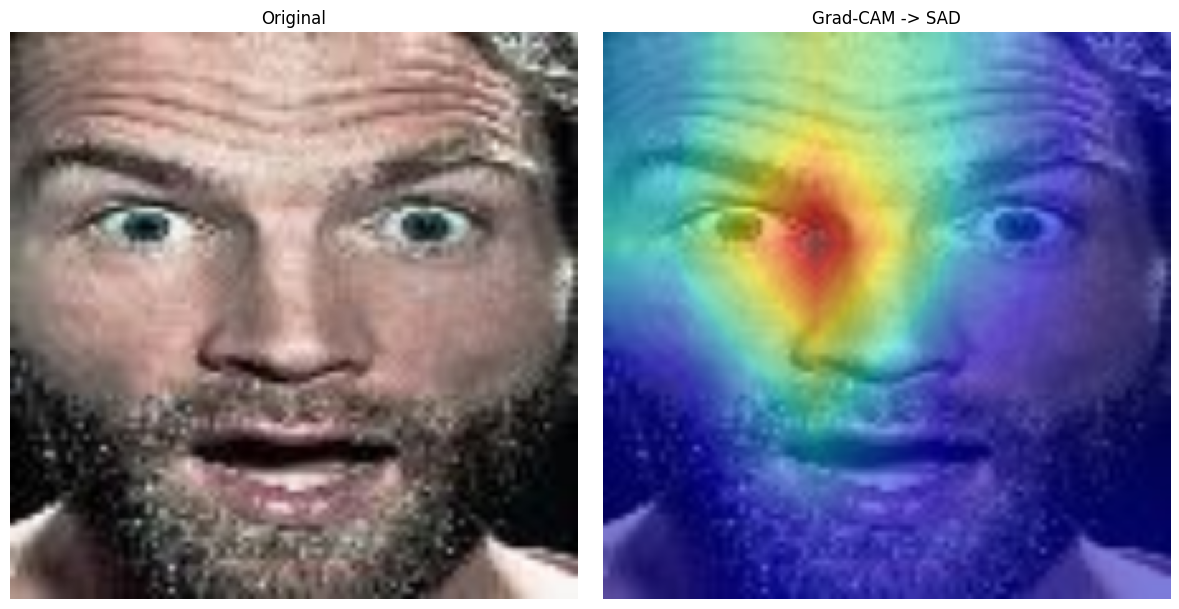

In [22]:
test_my_gradcam(path_to_image="src/image.png")